In [ ]:
import pandas as pd
import numpy as np
import pickle, json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
with open('failsafe_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)

with open('threshold_config.json') as f:
    thresh_config = json.load(f)

with open('features.json') as f:
    FEATURES = json.load(f)

DECISION_THRESHOLD = thresh_config['decision_threshold']
RISK_LOW           = thresh_config['risk_low_threshold']
RISK_HIGH          = thresh_config['risk_high_threshold']

print('Model & configs loaded!')
print(f'Decision threshold : {DECISION_THRESHOLD}')
print(f'Risk bands         : LOW < {RISK_LOW} | MEDIUM {RISK_LOW}-{RISK_HIGH} | HIGH >= {RISK_HIGH}')

Model & configs loaded!
Decision threshold : 0.2
Risk bands         : LOW < 0.35 | MEDIUM 0.35-0.65 | HIGH >= 0.65


In [ ]:
# Intervention rule map
# Structure:
#   feature -> {
#       'bad_when'   : 'high' or 'low'  (which direction is risky),
#       'threshold'  : numeric cutoff to decide high vs low,
#       'priority'   : 1 (urgent) / 2 (moderate) / 3 (advisory),
#       'category'   : intervention category label,
#       'intervention': the actual plan text shown to faculty
#   }

INTERVENTION_RULES = {

    'absences': {
        'bad_when'    : 'high',
        'threshold'   : 6,
        'priority'    : 1,
        'category'    : 'Attendance',
        'intervention': (
            'Student has high absences. '
            'Schedule an immediate one-on-one attendance review with the class advisor. '
            'Identify whether absences are health-related, family-related, or motivational. '
            'Issue a formal attendance warning if absences exceed 10.'
        )
    },

    'failures': {
        'bad_when'    : 'high',
        'threshold'   : 1,
        'priority'    : 1,
        'category'    : 'Academic History',
        'intervention': (
            'Student has a history of past failures. '
            'Assign a dedicated academic mentor for weekly check-ins. '
            'Enroll student in remedial support classes for the current subject. '
            'Set up monthly progress reviews with the HOD.'
        )
    },

    'G2': {
        'bad_when'    : 'low',
        'threshold'   : 10,
        'priority'    : 1,
        'category'    : 'Academic Performance',
        'intervention': (
            'Student scored below passing in the second period. '
            'Provide targeted tutoring sessions before the final exam. '
            'Review second period test papers with the student to identify weak topics. '
            'Schedule bi-weekly progress checks with subject teacher.'
        )
    },

    'G1': {
        'bad_when'    : 'low',
        'threshold'   : 10,
        'priority'    : 2,
        'category'    : 'Academic Performance',
        'intervention': (
            'Student showed early signs of struggle in the first period. '
            'Conduct an early diagnostic assessment to identify knowledge gaps. '
            'Offer access to recorded lectures and study guides. '
            'Pair with a higher-performing peer for study support.'
        )
    },

    'studytime': {
        'bad_when'    : 'low',
        'threshold'   : 2,
        'priority'    : 2,
        'category'    : 'Study Habits',
        'intervention': (
            'Student reports very low weekly study time. '
            'Introduce a structured personal study timetable with the class advisor. '
            'Recommend study skills workshop offered by the institution. '
            'Encourage use of library or supervised study hall sessions.'
        )
    },

    'Dalc': {
        'bad_when'    : 'high',
        'threshold'   : 3,
        'priority'    : 1,
        'category'    : 'Wellness',
        'intervention': (
            'Student has high weekday alcohol consumption. '
            'Refer to the student counselling or wellness center immediately. '
            'Coordinate with the student\'s guardian if appropriate. '
            'Provide information on substance use support resources discreetly.'
        )
    },

    'Walc': {
        'bad_when'    : 'high',
        'threshold'   : 3,
        'priority'    : 2,
        'category'    : 'Wellness',
        'intervention': (
            'Student has elevated weekend alcohol consumption. '
            'Suggest a confidential wellness session with a student counsellor. '
            'Encourage participation in weekend campus activities as an alternative. '
            'Monitor for associated impacts on Monday attendance.'
        )
    },

    'goout': {
        'bad_when'    : 'high',
        'threshold'   : 4,
        'priority'    : 2,
        'category'    : 'Time Management',
        'intervention': (
            'Student spends significant time going out with friends. '
            'Discuss time management strategies with the class advisor. '
            'Help student create a balanced weekly schedule combining social and study time. '
            'Highlight the correlation between social time and grades in a non-judgmental way.'
        )
    },

    'health': {
        'bad_when'    : 'low',
        'threshold'   : 2,
        'priority'    : 2,
        'category'    : 'Health Support',
        'intervention': (
            'Student reports poor health status which may be affecting attendance. '
            'Refer to the campus health center for a wellness check. '
            'Explore whether any academic accommodations are needed. '
            'Ensure student is aware of medical leave policies.'
        )
    },

    'higher': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 2,
        'category'    : 'Motivation',
        'intervention': (
            'Student does not aspire to pursue higher education. '
            'Schedule a career counselling session to explore goals and aspirations. '
            'Connect student with alumni or industry mentors to inspire motivation. '
            'Discuss how current performance affects future opportunities.'
        )
    },

    'internet': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 3,
        'category'    : 'Resource Access',
        'intervention': (
            'Student lacks internet access at home. '
            'Ensure student is aware of on-campus Wi-Fi and computer lab resources. '
            'Provide printed study materials where possible. '
            'Check institution\'s digital inclusion support programs.'
        )
    },

    'Medu': {
        'bad_when'    : 'low',
        'threshold'   : 2,
        'priority'    : 3,
        'category'    : 'Family Background',
        'intervention': (
            'Student comes from a low parental education background. '
            'Provide additional academic guidance that the family may not be able to offer. '
            'Connect student with first-generation student support groups if available. '
            'Assign a faculty mentor for regular academic guidance.'
        )
    },

    'Fedu': {
        'bad_when'    : 'low',
        'threshold'   : 2,
        'priority'    : 3,
        'category'    : 'Family Background',
        'intervention': (
            'Father has low education level — limited academic support at home. '
            'Ensure student has access to faculty office hours for guidance. '
            'Recommend peer tutoring programs available at the institution.'
        )
    },

    'famrel': {
        'bad_when'    : 'low',
        'threshold'   : 2,
        'priority'    : 2,
        'category'    : 'Family & Wellbeing',
        'intervention': (
            'Student reports poor family relationship quality. '
            'Refer to a student counsellor for emotional support. '
            'Monitor for signs of stress or disengagement in class. '
            'Provide a safe, non-judgmental space for the student to discuss concerns.'
        )
    },

    'schoolsup': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 2,
        'category'    : 'Academic Support',
        'intervention': (
            'Student is not currently receiving any school support. '
            'Enroll student in the institution\'s academic support program. '
            'Assign a subject teacher for additional doubt-clearing sessions.'
        )
    },

    'famsup': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 3,
        'category'    : 'Family Support',
        'intervention': (
            'Student lacks family educational support. '
            'Increase faculty check-ins to compensate for limited home support. '
            'Share study tips and progress updates with guardians via written communication.'
        )
    },

    'romantic': {
        'bad_when'    : 'high',
        'threshold'   : 1,
        'priority'    : 3,
        'category'    : 'Personal Factors',
        'intervention': (
            'Student is in a romantic relationship which may be affecting focus. '
            'Address this sensitively — avoid making it punitive. '
            'Counsel on balancing personal and academic life if student is open to it.'
        )
    },

    'traveltime': {
        'bad_when'    : 'high',
        'threshold'   : 3,
        'priority'    : 3,
        'category'    : 'Logistics',
        'intervention': (
            'Student has a long daily commute which may affect energy and punctuality. '
            'Explore whether any campus accommodation options are available. '
            'Consider scheduling this student\'s sessions at favorable times.'
        )
    },

    'freetime': {
        'bad_when'    : 'high',
        'threshold'   : 4,
        'priority'    : 3,
        'category'    : 'Time Management',
        'intervention': (
            'Student reports excessive free time which may indicate low engagement. '
            'Encourage joining academic clubs or project groups. '
            'Suggest structured self-study goals to productively use free time.'
        )
    },

    'paid': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 3,
        'category'    : 'Academic Support',
        'intervention': (
            'Student is not attending any paid extra classes. '
            'Recommend free tutoring or peer study groups available on campus. '
            'Check if institution offers any subsidized academic support programs.'
        )
    },

    'activities': {
        'bad_when'    : 'low',
        'threshold'   : 1,
        'priority'    : 3,
        'category'    : 'Engagement',
        'intervention': (
            'Student is not involved in any extracurricular activities. '
            'Encourage joining at least one club or sport for social engagement. '
            'Greater campus involvement is linked to improved academic motivation.'
        )
    },
}

print(f'Intervention rules loaded for {len(INTERVENTION_RULES)} features.')

Intervention rules loaded for 21 features.


In [ ]:
def get_risk_band(prob, low=RISK_LOW, high=RISK_HIGH):
    if prob >= high:
        return 'HIGH'
    elif prob >= low:
        return 'MEDIUM'
    else:
        return 'LOW'


def generate_interventions(student_data: dict,
                            shap_values_dict: dict,
                            top_n: int = 5) -> list:
    """
    Generate a prioritized intervention plan for a student.

    Parameters:
        student_data     : dict of feature_name -> value
        shap_values_dict : dict of feature_name -> shap_value
        top_n            : how many top SHAP factors to consider

    Returns:
        List of intervention dicts, sorted by priority then SHAP magnitude
    """
    # Sort features by absolute SHAP value — most impactful first
    ranked = sorted(shap_values_dict.items(),
                    key=lambda x: abs(x[1]), reverse=True)[:top_n]

    interventions = []

    for feat, shap_val in ranked:
        if feat not in INTERVENTION_RULES:
            continue

        rule     = INTERVENTION_RULES[feat]
        val      = student_data.get(feat)
        if val is None:
            continue

        # Check if the feature value is in the risky direction
        bad_when  = rule['bad_when']
        threshold = rule['threshold']
        is_risky  = (bad_when == 'high' and val >= threshold) or \
                    (bad_when == 'low'  and val <  threshold)

        # Only add an intervention if the value is in the risky direction
        # AND the SHAP value is pushing toward risk (positive) or is a top factor
        if is_risky or abs(shap_val) > 0.2:  # 0.2 = meaningful SHAP contribution
            interventions.append({
                'feature'      : feat,
                'value'        : val,
                'shap'         : round(float(shap_val), 4),
                'priority'     : rule['priority'],
                'category'     : rule['category'],
                'intervention' : rule['intervention'],
                'is_risky'     : is_risky,
            })

    # Sort: priority first, then by SHAP magnitude
    interventions.sort(key=lambda x: (x['priority'], -abs(x['shap'])))
    return interventions


def run_full_assessment(student_id: str,
                         student_data: dict,
                         model,
                         explainer,
                         features: list,
                         threshold: float = DECISION_THRESHOLD) -> dict:
    """
    Full pipeline: predict risk + SHAP + interventions for one student.

    Returns a structured assessment dict ready for FastAPI response.
    """
    import shap as shap_lib

    df_input    = pd.DataFrame([student_data])[features]
    prob        = float(model.predict_proba(df_input)[0][1])
    risk_score  = round(prob * 100, 1)
    risk_band   = get_risk_band(prob)
    prediction  = 'AT-RISK' if prob >= threshold else 'PASSING'

    sv          = explainer.shap_values(df_input)[0]
    shap_dict   = {feat: float(sv[i]) for i, feat in enumerate(features)}

    interventions = generate_interventions(student_data, shap_dict, top_n=5)

    return {
        'student_id'   : student_id,
        'risk_score'   : risk_score,
        'risk_band'    : risk_band,
        'prediction'   : prediction,
        'shap_values'  : shap_dict,
        'interventions': interventions,
        'top_factors'  : sorted(shap_dict.items(),
                                key=lambda x: abs(x[1]),
                                reverse=True)[:5],
    }


print('Intervention engine functions defined!')

Intervention engine functions defined!


In [ ]:
high_risk_student = {
    'traveltime': 2, 'studytime': 1,  'failures' : 2,
    'schoolsup' : 0, 'famsup'   : 0,  'paid'     : 0,
    'activities': 0, 'higher'   : 0,  'internet' : 0,
    'romantic'  : 1, 'famrel'   : 2,  'freetime' : 4,
    'goout'     : 5, 'Dalc'     : 4,  'Walc'     : 5,
    'health'    : 2, 'absences' : 18, 'G1'       : 6,
    'G2'        : 5, 'Medu'     : 1,  'Fedu'     : 1
}

assessment = run_full_assessment(
    student_id   = 'STU-001',
    student_data = high_risk_student,
    model        = model,
    explainer    = explainer,
    features     = FEATURES
)

# Display
print('=' * 65)
print(f'  FAILSAFE ASSESSMENT — Student {assessment["student_id"]}')
print('=' * 65)
print(f'  Risk Score  : {assessment["risk_score"]}%')
print(f'  Risk Band   : {assessment["risk_band"]}')
print(f'  Prediction  : {assessment["prediction"]}')
print()
print(f'  INTERVENTION PLAN ({len(assessment["interventions"])} actions):')
print()

PRIORITY_LABELS = {1: '🔴 URGENT', 2: '🟡 MODERATE', 3: '🔵 ADVISORY'}

for i, item in enumerate(assessment['interventions'], 1):
    p_label = PRIORITY_LABELS.get(item['priority'], 'ADVISORY')
    print(f'  [{i}] {p_label}  |  {item["category"]}  |  {item["feature"]} = {item["value"]}')
    # Word wrap the intervention text
    words = item['intervention'].split('. ')
    for w in words:
        if w.strip():
            print(f'       • {w.strip()}.')
    print()

print('=' * 65)

  FAILSAFE ASSESSMENT — Student STU-001
  Risk Score  : 98.3%
  Risk Band   : HIGH
  Prediction  : AT-RISK

  INTERVENTION PLAN (4 actions):

  [1] 🔴 URGENT  |  Academic Performance  |  G2 = 5
       • Student scored below passing in the second period.
       • Provide targeted tutoring sessions before the final exam.
       • Review second period test papers with the student to identify weak topics.
       • Schedule bi-weekly progress checks with subject teacher..

  [2] 🟡 MODERATE  |  Academic Performance  |  G1 = 6
       • Student showed early signs of struggle in the first period.
       • Conduct an early diagnostic assessment to identify knowledge gaps.
       • Offer access to recorded lectures and study guides.
       • Pair with a higher-performing peer for study support..

  [3] 🟡 MODERATE  |  Wellness  |  Walc = 5
       • Student has elevated weekend alcohol consumption.
       • Suggest a confidential wellness session with a student counsellor.
       • Encourage partici

In [ ]:
low_risk_student = {
    'traveltime': 1, 'studytime': 3,  'failures' : 0,
    'schoolsup' : 0, 'famsup'   : 1,  'paid'     : 1,
    'activities': 1, 'higher'   : 1,  'internet' : 1,
    'romantic'  : 0, 'famrel'   : 5,  'freetime' : 2,
    'goout'     : 2, 'Dalc'     : 1,  'Walc'     : 1,
    'health'    : 5, 'absences' : 2,  'G1'       : 15,
    'G2'        : 16,'Medu'     : 4,  'Fedu'     : 3
}

assessment_low = run_full_assessment(
    student_id   = 'STU-002',
    student_data = low_risk_student,
    model        = model,
    explainer    = explainer,
    features     = FEATURES
)

print('=' * 65)
print(f'  FAILSAFE ASSESSMENT — Student {assessment_low["student_id"]}')
print('=' * 65)
print(f'  Risk Score  : {assessment_low["risk_score"]}%')
print(f'  Risk Band   : {assessment_low["risk_band"]}')
print(f'  Prediction  : {assessment_low["prediction"]}')

if assessment_low['interventions']:
    print(f'\n  Interventions:')
    for item in assessment_low['interventions']:
        print(f'  [{item["priority"]}] {item["category"]} — {item["feature"]} = {item["value"]}')
else:
    print('\n  No critical interventions needed. Student is on track.')
    print('  Continue monitoring at next assessment cycle.')

print('=' * 65)

  FAILSAFE ASSESSMENT — Student STU-002
  Risk Score  : 0.8%
  Risk Band   : LOW
  Prediction  : PASSING

  Interventions:
  [1] Academic Performance — G2 = 16
  [2] Academic Performance — G1 = 15
  [2] Family & Wellbeing — famrel = 5


In [ ]:
def batch_assess(df_students: pd.DataFrame,
                  model, explainer, features,
                  threshold=DECISION_THRESHOLD) -> pd.DataFrame:
    """
    Run assessment for all students in a DataFrame.
    Returns a summary DataFrame with risk scores, bands, and top intervention.
    """
    results = []

    for idx, row in df_students.iterrows():
        student_data = row[features].to_dict()
        assessment   = run_full_assessment(
            student_id   = str(idx),
            student_data = student_data,
            model        = model,
            explainer    = explainer,
            features     = features,
            threshold    = threshold
        )

        top_intervention = (
            assessment['interventions'][0]['category']
            if assessment['interventions'] else 'None'
        )
        num_interventions = len(assessment['interventions'])

        results.append({
            'student_id'       : assessment['student_id'],
            'risk_score'       : assessment['risk_score'],
            'risk_band'        : assessment['risk_band'],
            'prediction'       : assessment['prediction'],
            'num_interventions': num_interventions,
            'top_intervention' : top_intervention,
            'top_feature'      : assessment['top_factors'][0][0] if assessment['top_factors'] else '',
        })

    return pd.DataFrame(results).sort_values('risk_score', ascending=False)


# Load test set for batch demo
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

print('Running batch assessment on test set...')
batch_results = batch_assess(X_test, model, explainer, FEATURES)

print(f'Batch complete! {len(batch_results)} students assessed.')
print(f'\nSummary:')
print(batch_results['risk_band'].value_counts().to_string())
print(f'\nTop 10 At-Risk Students:')
print(batch_results.head(10).to_string(index=False))

Running batch assessment on test set...
Batch complete! 79 students assessed.

Summary:
risk_band
LOW       51
HIGH      24
MEDIUM     4

Top 10 At-Risk Students:
student_id  risk_score risk_band prediction  num_interventions     top_intervention top_feature
        67        99.2      HIGH    AT-RISK                  4 Academic Performance          G2
        45        99.0      HIGH    AT-RISK                  3 Academic Performance          G2
        72        99.0      HIGH    AT-RISK                  4 Academic Performance          G2
        54        98.9      HIGH    AT-RISK                  4 Academic Performance          G2
        78        98.7      HIGH    AT-RISK                  3 Academic Performance          G2
         0        98.4      HIGH    AT-RISK                  4 Academic Performance          G2
        20        98.2      HIGH    AT-RISK                  5 Academic Performance          G2
        13        97.8      HIGH    AT-RISK                  3 Academ

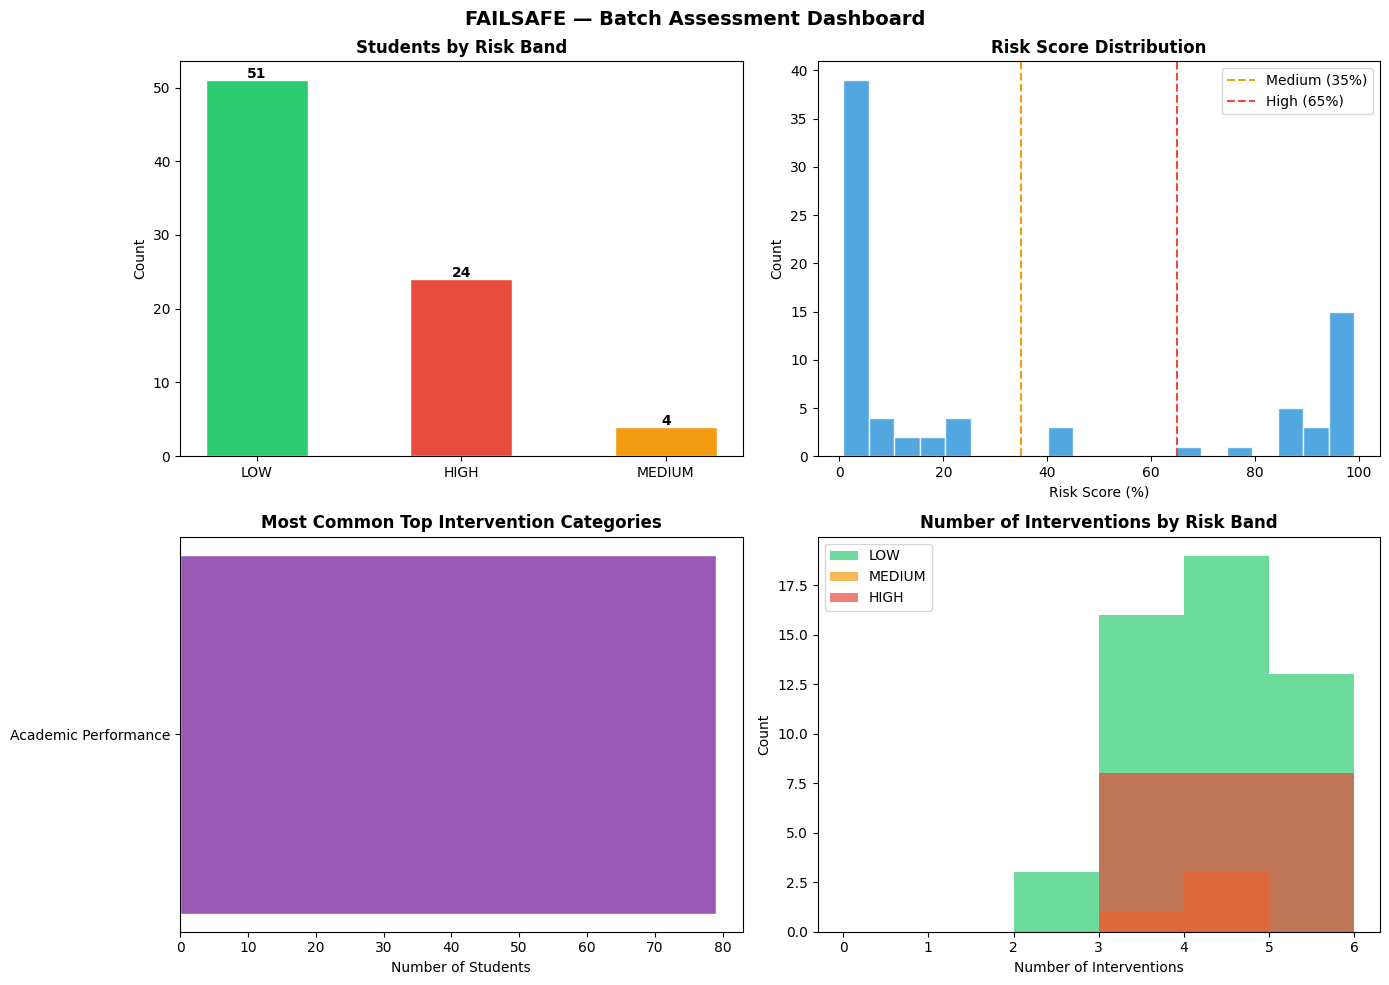

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Risk band distribution
colors_map  = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'}
band_counts = batch_results['risk_band'].value_counts()
axes[0, 0].bar(band_counts.index,
               band_counts.values,
               color=[colors_map[b] for b in band_counts.index],
               edgecolor='white', width=0.5)
axes[0, 0].set_title('Students by Risk Band', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, (band, cnt) in enumerate(band_counts.items()):
    axes[0, 0].text(i, cnt + 0.3, str(cnt), ha='center', fontweight='bold')

# 2. Risk score histogram
axes[0, 1].hist(batch_results['risk_score'], bins=20,
                color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(x=RISK_LOW * 100,  color='#f39c12', linestyle='--',
                   label=f'Medium ({int(RISK_LOW*100)}%)')
axes[0, 1].axvline(x=RISK_HIGH * 100, color='#e74c3c', linestyle='--',
                   label=f'High ({int(RISK_HIGH*100)}%)')
axes[0, 1].set_title('Risk Score Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Risk Score (%)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# 3. Most common intervention categories
top_cats = batch_results['top_intervention'].value_counts().head(8)
axes[1, 0].barh(top_cats.index[::-1], top_cats.values[::-1],
                color='#9b59b6', edgecolor='white')
axes[1, 0].set_title('Most Common Top Intervention Categories', fontweight='bold')
axes[1, 0].set_xlabel('Number of Students')

# 4. Number of interventions per risk band
band_order = ['LOW', 'MEDIUM', 'HIGH']
band_colors = ['#2ecc71', '#f39c12', '#e74c3c']
for band, color in zip(band_order, band_colors):
    subset = batch_results[batch_results['risk_band'] == band]['num_interventions']
    if len(subset) > 0:
        axes[1, 1].hist(subset, alpha=0.7, label=band, color=color, bins=range(0, 7))
axes[1, 1].set_title('Number of Interventions by Risk Band', fontweight='bold')
axes[1, 1].set_xlabel('Number of Interventions')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.suptitle('FAILSAFE — Batch Assessment Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

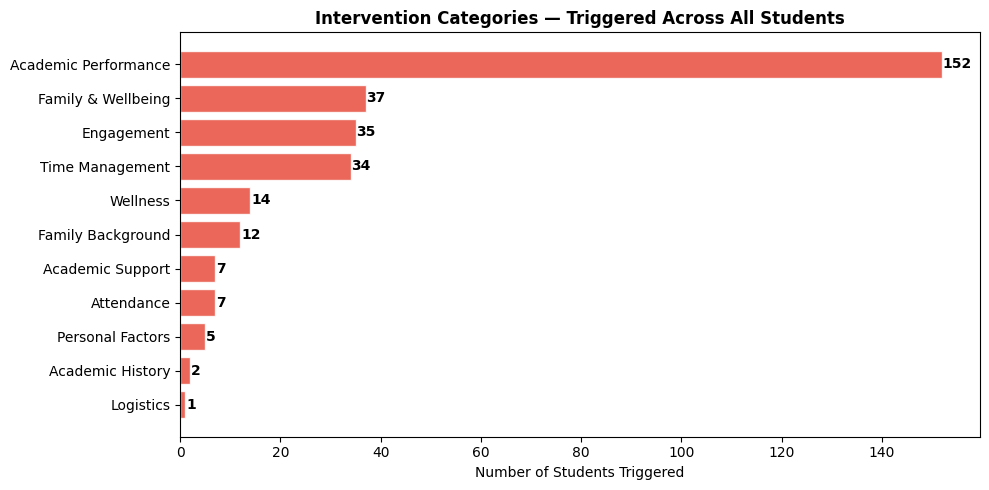

Intervention trigger counts:
Academic Performance    152
Family & Wellbeing       37
Engagement               35
Time Management          34
Wellness                 14
Family Background        12
Academic Support          7
Attendance                7
Personal Factors          5
Academic History          2
Logistics                 1


In [ ]:
# Run full intervention detail for all test students
import shap as shap_lib

all_interventions = []
for idx, row in X_test.iterrows():
    student_data = row[FEATURES].to_dict()
    df_input     = pd.DataFrame([student_data])[FEATURES]
    sv           = explainer.shap_values(df_input)[0]
    shap_dict    = {feat: float(sv[i]) for i, feat in enumerate(FEATURES)}
    items        = generate_interventions(student_data, shap_dict, top_n=5)
    for item in items:
        all_interventions.append(item['category'])

cat_counts = pd.Series(all_interventions).value_counts()

plt.figure(figsize=(10, 5))
bars = plt.barh(cat_counts.index[::-1], cat_counts.values[::-1],
                color='#e74c3c', edgecolor='white', alpha=0.85)
plt.title('Intervention Categories — Triggered Across All Students', fontweight='bold')
plt.xlabel('Number of Students Triggered')
for bar, val in zip(bars, cat_counts.values[::-1]):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('Intervention trigger counts:')
print(cat_counts.to_string())

In [ ]:
import os
os.makedirs('backend', exist_ok=True)

module_code = '''
"""
FAILSAFE — Intervention Engine
intervention_engine.py

Imported by FastAPI backend to generate personalized
intervention plans from SHAP values and student data.
"""

import pandas as pd
import numpy as np
from typing import List, Dict, Any


INTERVENTION_RULES = {
    "absences"  : {"bad_when": "high", "threshold": 6,  "priority": 1, "category": "Attendance",         "intervention": "Student has high absences. Schedule an immediate one-on-one attendance review with the class advisor. Identify whether absences are health-related, family-related, or motivational. Issue a formal attendance warning if absences exceed 10."},
    "failures"  : {"bad_when": "high", "threshold": 1,  "priority": 1, "category": "Academic History",   "intervention": "Student has a history of past failures. Assign a dedicated academic mentor for weekly check-ins. Enroll student in remedial support classes for the current subject. Set up monthly progress reviews with the HOD."},
    "G2"        : {"bad_when": "low",  "threshold": 10, "priority": 1, "category": "Academic Performance","intervention": "Student scored below passing in the second period. Provide targeted tutoring sessions before the final exam. Review second period test papers with the student to identify weak topics. Schedule bi-weekly progress checks with subject teacher."},
    "G1"        : {"bad_when": "low",  "threshold": 10, "priority": 2, "category": "Academic Performance","intervention": "Student showed early signs of struggle in the first period. Conduct an early diagnostic assessment to identify knowledge gaps. Offer access to recorded lectures and study guides. Pair with a higher-performing peer for study support."},
    "studytime" : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Study Habits",        "intervention": "Student reports very low weekly study time. Introduce a structured personal study timetable with the class advisor. Recommend study skills workshop offered by the institution."},
    "Dalc"      : {"bad_when": "high", "threshold": 3,  "priority": 1, "category": "Wellness",            "intervention": "Student has high weekday alcohol consumption. Refer to the student counselling or wellness center immediately. Coordinate with the student guardian if appropriate."},
    "Walc"      : {"bad_when": "high", "threshold": 3,  "priority": 2, "category": "Wellness",            "intervention": "Student has elevated weekend alcohol consumption. Suggest a confidential wellness session with a student counsellor. Monitor for associated impacts on Monday attendance."},
    "goout"     : {"bad_when": "high", "threshold": 4,  "priority": 2, "category": "Time Management",     "intervention": "Student spends significant time going out with friends. Discuss time management strategies with the class advisor. Help student create a balanced weekly schedule."},
    "health"    : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Health Support",      "intervention": "Student reports poor health status which may be affecting attendance. Refer to the campus health center for a wellness check. Explore whether any academic accommodations are needed."},
    "higher"    : {"bad_when": "low",  "threshold": 1,  "priority": 2, "category": "Motivation",          "intervention": "Student does not aspire to pursue higher education. Schedule a career counselling session to explore goals. Connect student with alumni or industry mentors."},
    "internet"  : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Resource Access",     "intervention": "Student lacks internet access at home. Ensure student is aware of on-campus Wi-Fi and computer lab resources. Provide printed study materials where possible."},
    "Medu"      : {"bad_when": "low",  "threshold": 2,  "priority": 3, "category": "Family Background",   "intervention": "Student comes from a low parental education background. Provide additional academic guidance. Connect with first-generation student support groups."},
    "Fedu"      : {"bad_when": "low",  "threshold": 2,  "priority": 3, "category": "Family Background",   "intervention": "Father has low education level. Ensure student has access to faculty office hours. Recommend peer tutoring programs."},
    "famrel"    : {"bad_when": "low",  "threshold": 2,  "priority": 2, "category": "Family & Wellbeing",  "intervention": "Student reports poor family relationship quality. Refer to a student counsellor for emotional support. Monitor for signs of stress or disengagement."},
    "schoolsup" : {"bad_when": "low",  "threshold": 1,  "priority": 2, "category": "Academic Support",    "intervention": "Student is not currently receiving any school support. Enroll in the institution academic support program. Assign a subject teacher for additional sessions."},
    "famsup"    : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Family Support",      "intervention": "Student lacks family educational support. Increase faculty check-ins. Share study tips and progress updates with guardians."},
    "romantic"  : {"bad_when": "high", "threshold": 1,  "priority": 3, "category": "Personal Factors",    "intervention": "Student is in a romantic relationship which may be affecting focus. Counsel sensitively on balancing personal and academic life."},
    "traveltime": {"bad_when": "high", "threshold": 3,  "priority": 3, "category": "Logistics",           "intervention": "Student has a long daily commute. Explore campus accommodation options. Consider scheduling sessions at favorable times."},
    "freetime"  : {"bad_when": "high", "threshold": 4,  "priority": 3, "category": "Time Management",     "intervention": "Student reports excessive free time indicating low engagement. Encourage joining academic clubs or project groups."},
    "paid"      : {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Academic Support",    "intervention": "Student is not attending any paid extra classes. Recommend free tutoring or peer study groups on campus."},
    "activities": {"bad_when": "low",  "threshold": 1,  "priority": 3, "category": "Engagement",          "intervention": "Student is not involved in any extracurricular activities. Encourage joining at least one club or sport."},
}


def get_risk_band(prob: float,
                   low: float = 0.35,
                   high: float = 0.65) -> str:
    if prob >= high:
        return "HIGH"
    elif prob >= low:
        return "MEDIUM"
    return "LOW"


def generate_interventions(student_data: Dict[str, Any],
                            shap_values_dict: Dict[str, float],
                            top_n: int = 5) -> List[Dict]:
    ranked = sorted(shap_values_dict.items(),
                    key=lambda x: abs(x[1]), reverse=True)[:top_n]
    interventions = []
    for feat, shap_val in ranked:
        if feat not in INTERVENTION_RULES:
            continue
        rule     = INTERVENTION_RULES[feat]
        val      = student_data.get(feat)
        if val is None:
            continue
        bad_when  = rule["bad_when"]
        threshold = rule["threshold"]
        is_risky  = (bad_when == "high" and val >= threshold) or \\
                    (bad_when == "low"  and val <  threshold)
        if is_risky or abs(shap_val) > 0.2:
            interventions.append({
                "feature"      : feat,
                "value"        : val,
                "shap"         : round(float(shap_val), 4),
                "priority"     : rule["priority"],
                "category"     : rule["category"],
                "intervention" : rule["intervention"],
            })
    interventions.sort(key=lambda x: (x["priority"], -abs(x["shap"])))
    return interventions


def run_full_assessment(student_id: str,
                         student_data: Dict[str, Any],
                         model,
                         explainer,
                         features: List[str],
                         threshold: float = 0.45) -> Dict:
    df_input   = pd.DataFrame([student_data])[features]
    prob       = float(model.predict_proba(df_input)[0][1])
    risk_score = round(prob * 100, 1)
    risk_band  = get_risk_band(prob)
    prediction = "AT-RISK" if prob >= threshold else "PASSING"
    sv         = explainer.shap_values(df_input)[0]
    shap_dict  = {feat: float(sv[i]) for i, feat in enumerate(features)}
    return {
        "student_id"   : student_id,
        "risk_score"   : risk_score,
        "risk_band"    : risk_band,
        "prediction"   : prediction,
        "shap_values"  : shap_dict,
        "interventions": generate_interventions(student_data, shap_dict),
        "top_factors"  : sorted(shap_dict.items(),
                                key=lambda x: abs(x[1]),
                                reverse=True)[:5],
    }
'''

with open('backend/intervention_engine.py', 'w') as f:
    f.write(module_code.strip())

print('Exported to backend/intervention_engine.py')
print('This file will be imported directly by FastAPI.')

Exported to backend/intervention_engine.py
This file will be imported directly by FastAPI.
